<a href="https://colab.research.google.com/github/ginasoft/vision-computacional/blob/main/Clase07_Unidad_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# TensorFlow nos permite crear redes neuronales sin programar
# todas las matematicas desde cero.
import tensorflow as tf
# Keras es la parte de TensorFlow que simplifica las cosas.
# datasets -> carga conjuntos de datos ya preparados
# layers   -> crea las capas de la red neuronal
# models   -> construye el modelo completo
from tensorflow import keras
from keras import datasets, layers, models

In [2]:
# datasets.cifar10.load_data() carga el conjunto CIFAR-10.
# Son 60.000 imagenes a color de 32x32 pixeles, divididas en 10 categorias.
# 50.000 imagenes se usan para entrenar la red.
# 10.000 imagenes se usan para testear que tan bien aprendio.
# Cada imagen tiene una etiqueta (un numero del 0 al 9) que indica su clase.

(imagenes_entrenamiento, etiquetas_entrenamiento), (imagenes_prueba, etiquetas_prueba) = datasets.cifar10.load_data()

# Nombres de las 10 clases (el orden corresponde a las etiquetas 0..9)
nombres_clases = ['avion', 'automovil', 'pajaro', 'gato', 'ciervo',
                  'perro', 'rana', 'caballo', 'barco', 'camion']

# Verificamos las dimensiones de los datos
print("Forma imagenes entrenamiento:", imagenes_entrenamiento.shape)
print("Forma imagenes prueba:", imagenes_prueba.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 8s 0us/step
Forma imagenes entrenamiento: (50000, 32, 32, 3)
Forma imagenes prueba: (10000, 32, 32, 3)


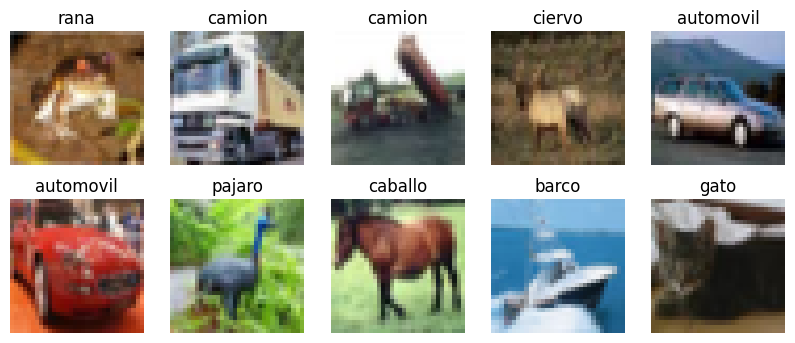

In [3]:
# Mostramos las primeras 10 imagenes con su etiqueta para entender el dataset
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(imagenes_entrenamiento[i])
    plt.title(nombres_clases[etiquetas_entrenamiento[i][0]])
    plt.axis('off')
plt.show()

In [4]:
# Los pixeles van de 0 a 255. Dividimos por 255 para que queden entre 0 y 1.
# Esto da estabilidad numerica y hace que la red aprenda mas rapido.
imagenes_entrenamiento = imagenes_entrenamiento / 255.0
imagenes_prueba = imagenes_prueba / 255.0

In [6]:
# models.Sequential() crea una red donde las capas se agregan
# una detras de la otra, en orden. La salida de una capa entra a la siguiente.
modelo_cnn = models.Sequential()

In [7]:
# La entrada son imagenes de 32x32 pixeles con 3 canales (RGB).
modelo_cnn.add(layers.Input(shape=(32, 32, 3)))

In [8]:
# filters=32 -> la red aprende 32 filtros distintos, cada uno busca un patron.
# kernel_size=(3,3) -> el filtro es una matriz de 3x3 pixeles.
# padding='same' -> agrega ceros en los bordes para no perder informacion de los extremos.
# activation='relu' -> apaga los valores negativos y deja pasar los positivos.
modelo_cnn.add(layers.Conv2D(
    filters=32,
    kernel_size=(3, 3),
    padding='same',
    activation='relu'
))

# MaxPooling toma grupos de 2x2 y se queda con el valor mas grande.
# Reduce el alto y el ancho a la mitad (32x32 -> 16x16).
modelo_cnn.add(layers.MaxPooling2D((2, 2)))

In [9]:
# Aumentamos a 64 filtros para detectar patrones mas complejos.
modelo_cnn.add(layers.Conv2D(
    filters=64,
    kernel_size=(3, 3),
    padding='same',
    activation='relu'
))
modelo_cnn.add(layers.MaxPooling2D((2, 2)))  # 16x16 -> 8x8

In [10]:
# Tercer bloque para que la red ensamble partes de objetos.
modelo_cnn.add(layers.Conv2D(
    filters=64,
    kernel_size=(3, 3),
    padding='same',
    activation='relu'
))
modelo_cnn.add(layers.MaxPooling2D((2, 2)))  # 8x8 -> 4x4

In [11]:
# Convierte los mapas de caracteristicas (4x4x64) en un unico vector 1D
# para poder pasarlos a las capas densas. No tiene parametros entrenables.
modelo_cnn.add(layers.Flatten())

In [12]:
# Capa densa: cada neurona se conecta con todas las anteriores.
# Combina todas las caracteristicas aprendidas para tomar la decision.
modelo_cnn.add(layers.Dense(64, activation='relu'))

In [13]:
# 10 neuronas, una por cada clase. Softmax convierte la salida
# en probabilidades que suman 1.
modelo_cnn.add(layers.Dense(10, activation='softmax'))

In [14]:
modelo_cnn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# compile() configura el modelo antes de entrenar.

# optimizer='adam' -> ajusta los pesos automaticamente. Va rapido cuando el error
#   es grande y con mas cuidado cuando se acerca a la respuesta correcta.
# loss='sparse_categorical_crossentropy' -> mide la prediccion vs la clase real.
#   Usamos la version "sparse" porque las etiquetas son enteros (0..9), no vectores.
# metrics=['accuracy'] -> mide el porcentaje de aciertos.
modelo_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [16]:
# epochs=10 -> la red ve el set de entrenamiento completo 10 veces.
# validation_data -> en cada epoca evalua con imagenes de prueba para ver
#   si esta generalizando o solo memorizando.
historial_entrenamiento = modelo_cnn.fit(
    imagenes_entrenamiento,
    etiquetas_entrenamiento,
    epochs=10,
    validation_data=(imagenes_prueba, etiquetas_prueba)
)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - accuracy: 0.4666 - loss: 1.4619 - val_accuracy: 0.5824 - val_loss: 1.1762
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.6341 - loss: 1.0474 - val_accuracy: 0.6360 - val_loss: 1.0611
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.6906 - loss: 0.8892 - val_accuracy: 0.6903 - val_loss: 0.8845
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7258 - loss: 0.7874 - val_accuracy: 0.7132 - val_loss: 0.8266
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7514 - loss: 0.7123 - val_accuracy: 0.7221 - val_loss: 0.8131
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7714 - loss: 0.6559 - val_accuracy: 0.7137 - val_loss: 0.8418
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7873 - loss: 0.6057 - val_accuracy: 0.7250 - val_loss: 0.8262
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8031 - loss: 0.5611 -

In [17]:
# evaluate prueba la red con imagenes nuevas que no uso para aprender los pesos.
perdida_test, precision_test = modelo_cnn.evaluate(imagenes_prueba, etiquetas_prueba)

print("Precision en test:", precision_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7389 - loss: 0.8063
Precision en test: 0.7389000058174133


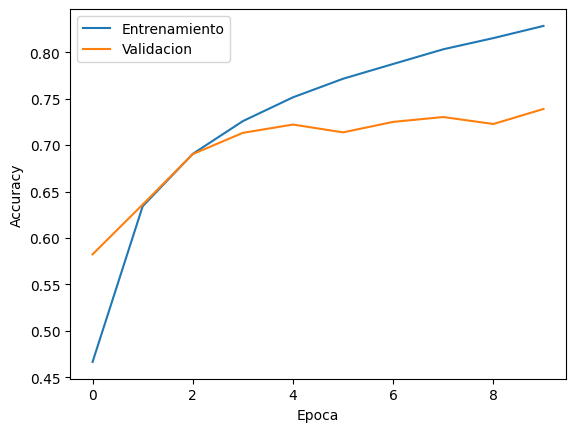

In [18]:
# Graficamos la accuracy de entrenamiento vs validacion epoca por epoca.
# Si la curva de entrenamiento sube mucho mas que la de validacion -> sobreajuste.
plt.plot(historial_entrenamiento.history['accuracy'], label='Entrenamiento')
plt.plot(historial_entrenamiento.history['val_accuracy'], label='Validacion')
plt.xlabel('Epoca')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Prediccion del modelo: gato
Etiqueta real: gato
Resultado: ACERTO


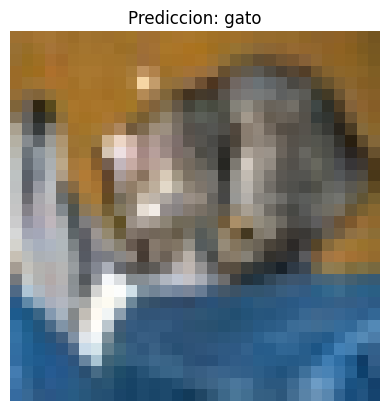

In [19]:
# predict genera, para cada imagen, una lista de 10 probabilidades (una por clase).
# Usamos imagenes_prueba porque ya tienen el formato correcto (32x32x3, normalizadas)
# y la red NO las uso para aprender los pesos, asi que sirven como test real.
predicciones = modelo_cnn.predict(imagenes_prueba)

# Elegimos una imagen del set de prueba.
indice_ejemplo = 0

# argmax busca la probabilidad mas alta y nos da su posicion (la clase predicha).
clase_predicha = np.argmax(predicciones[indice_ejemplo])
clase_real = etiquetas_prueba[indice_ejemplo][0]

print("Prediccion del modelo:", nombres_clases[clase_predicha])
print("Etiqueta real:", nombres_clases[clase_real])

# Comparamos si acerto o no.
if clase_predicha == clase_real:
    print("Resultado: ACERTO")
else:
    print("Resultado: NO ACERTO")

# Mostramos la imagen. CIFAR-10 es a color, asi que NO usamos cmap='gray'.
plt.imshow(imagenes_prueba[indice_ejemplo])
plt.title("Prediccion: " + nombres_clases[clase_predicha])
plt.axis('off')
plt.show()

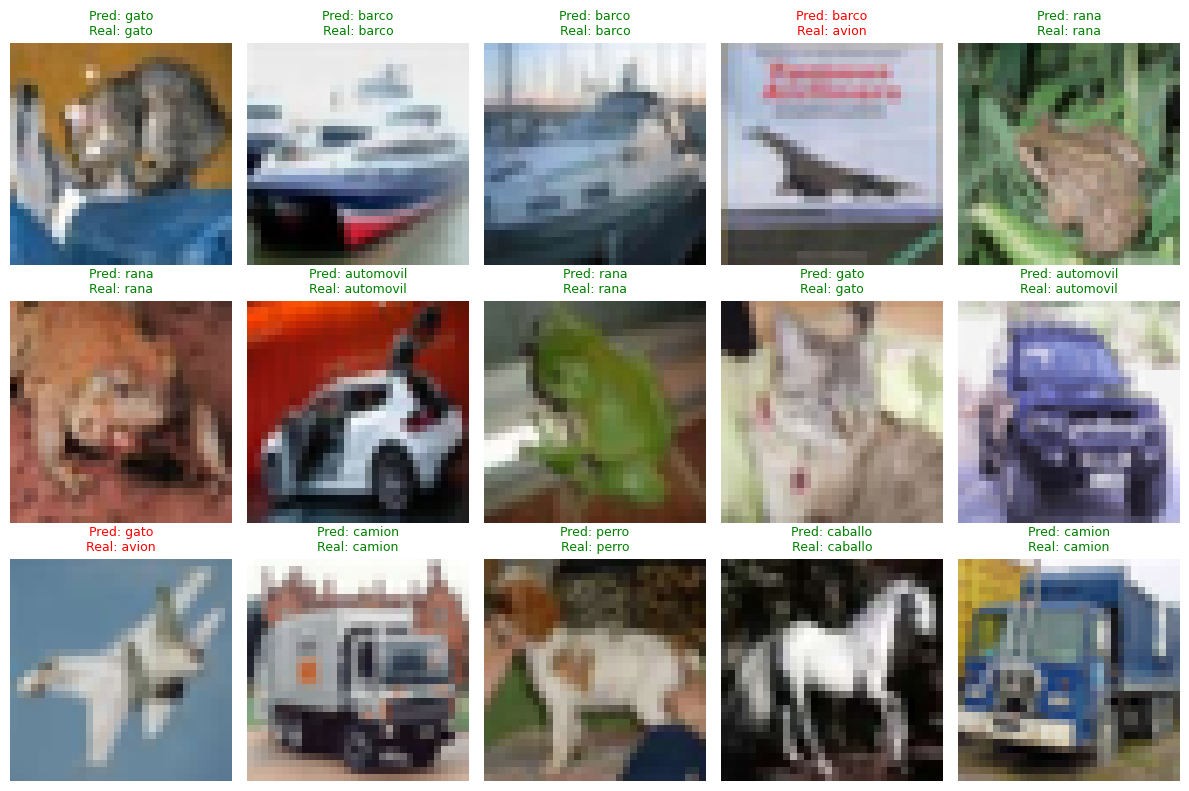

In [20]:
# Mostramos 15 imagenes del set de prueba con su prediccion.
# En verde si la red acerto, en rojo si se equivoco.
plt.figure(figsize=(12, 8))
for i in range(15):
    plt.subplot(3, 5, i + 1)
    plt.imshow(imagenes_prueba[i])

    clase_predicha = np.argmax(predicciones[i])
    clase_real = etiquetas_prueba[i][0]

    # Color del titulo segun si acerto o no.
    color = 'green' if clase_predicha == clase_real else 'red'

    plt.title("Pred: " + nombres_clases[clase_predicha] +
              "\nReal: " + nombres_clases[clase_real],
              color=color, fontsize=9)
    plt.axis('off')

plt.tight_layout()
plt.show()